In [10]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [11]:
class BatsmanState(TypedDict):
    name: str
    runs: int
    balls_faced: int
    fours: int
    sixes: int

    bpb: float
    strike_rate: float
    boundary_percentage: float
    batsman_stats: dict
    summary: str

In [23]:
def calculate_strike_rate(state: BatsmanState) -> float:
    if state['balls_faced'] == 0:
        return 0.0
    strike_rate = (state['runs'] / state['balls_faced']) * 100

    # state['strike_rate'] = strike_rate
    # return state

    return {'strike_rate': strike_rate}

def calculate_bpb(state: BatsmanState) -> float:
    if state['balls_faced'] == 0:
        return 0.0
    bpb = state['balls_faced'] / (state['fours'] + state['sixes']) if (state['fours'] + state['sixes']) > 0 else 0
    # state['bpb'] = bpb
    # return state
    return {'bpb': bpb}

def calculate_boundary_percentage(state: BatsmanState) -> float:
    if state['balls_faced'] == 0:
        return 0.0
    total_boundaries = state['fours'] * 4 + state['sixes'] * 6
    boundary_percentage = (total_boundaries / state['runs']) * 100 if state['runs'] > 0 else 0
    # state['boundary_percentage'] = boundary_percentage
    # return state
    return {'boundary_percentage': boundary_percentage}

def calculate_batsman_stats(state: BatsmanState) -> BatsmanState:
    batsman_stats = { 
        "name": state["name"],
        "runs": state["runs"],
        "balls_faced": state["balls_faced"],
        "fours": state["fours"],
        "sixes": state["sixes"],
        "strike_rate": calculate_strike_rate(state),
        "bpb": calculate_bpb(state),
        "boundary_percentage": calculate_boundary_percentage(state)
    }
    # state["batsman_stats"] = batsman_stats
    # return state
    return {"batsman_stats": batsman_stats}

In [24]:
def summary(state: BatsmanState) -> str:
    summary =  (f"Batsman: {state['name']}\n"
            f"Runs: {state['runs']}\n"
            f"Balls Faced: {state['balls_faced']}\n"
            f"Fours: {state['fours']}\n"
            f"Sixes: {state['sixes']}\n"
            f"Strike Rate: {state['strike_rate']:.2f}\n"
            f"Boundaries per Ball (BPB): {state['bpb']:.2f}\n"
            f"Boundary Percentage: {state['boundary_percentage']:.2f}%")
    return {"summary": summary}

In [25]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_strike_rate', calculate_strike_rate)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_percentage', calculate_boundary_percentage)
graph.add_node('calculate_batsman_stats', calculate_batsman_stats)
graph.add_node('summary', summary)

# Edge connections

# START → calculations
graph.add_edge(START, 'calculate_strike_rate')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_percentage')
graph.add_edge(START, 'calculate_batsman_stats')

# Calculations → summary
graph.add_edge('calculate_strike_rate', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundary_percentage', 'summary')
graph.add_edge("calculate_batsman_stats", "summary")

# Summary → END
graph.add_edge('summary', END)

workflow = graph.compile()

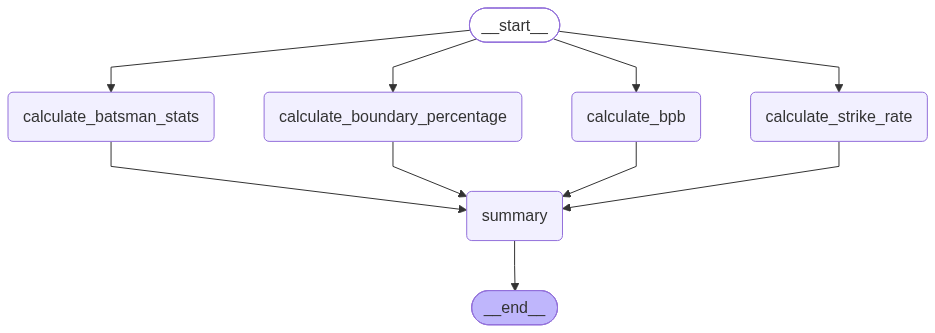

In [26]:
workflow

In [27]:
intial_state = {
    "name": "John Doe",
    "runs": 75,
    "balls_faced": 50,
    "fours": 8,
    "sixes": 2,
    "bpb": 0.0,
    "strike_rate": 0.0,
    "boundary_percentage": 0.0,
    "batsman_stats": {},
    "summary": ""
}

workflow.invoke(intial_state)

{'name': 'John Doe',
 'runs': 75,
 'balls_faced': 50,
 'fours': 8,
 'sixes': 2,
 'bpb': 5.0,
 'strike_rate': 150.0,
 'boundary_percentage': 58.666666666666664,
 'batsman_stats': {'name': 'John Doe',
  'runs': 75,
  'balls_faced': 50,
  'fours': 8,
  'sixes': 2,
  'strike_rate': {'strike_rate': 150.0},
  'bpb': {'bpb': 5.0},
  'boundary_percentage': {'boundary_percentage': 58.666666666666664}},
 'summary': 'Batsman: John Doe\nRuns: 75\nBalls Faced: 50\nFours: 8\nSixes: 2\nStrike Rate: 150.00\nBoundaries per Ball (BPB): 5.00\nBoundary Percentage: 58.67%'}